In [1]:
import ants
import antspynet
import torch
import torchio as tio
import numpy as np

In [2]:
mri_path = r"C:\Users\hp\Downloads\IXI-T1\IXI425-IOP-0988-T1.nii.gz" 

**[CHECKED]**

In [3]:
image = ants.image_read(mri_path)
print(image.orientation) 

AIL


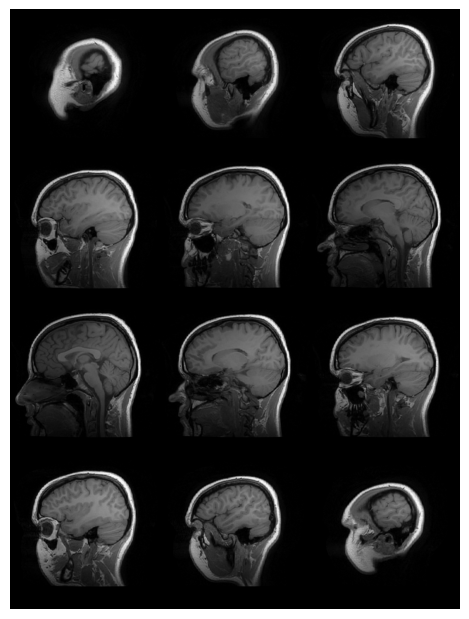

In [4]:
ants.plot(image)

**[CHECKED]**

In [5]:
reoriented_image = ants.reorient_image2(image, orientation='RAS')
print(reoriented_image.orientation)

RAS


**[CHECKED]**

In [6]:
brain_mask = antspynet.brain_extraction(reoriented_image, modality="t1", verbose=False)

In [7]:
print(reoriented_image.shape)
print(brain_mask.shape)

(146, 256, 256)
(146, 256, 256)


**[CHECKED]**

In [8]:
# Convert to TorchIO ScalarImage
torchio_image = tio.ScalarImage(tensor=torch.from_numpy(reoriented_image.numpy()).unsqueeze(0))
torchio_mask = tio.ScalarImage(tensor=torch.from_numpy(brain_mask.numpy()).unsqueeze(0))

print(torchio_image.shape)
print(torchio_mask.shape)

(1, 146, 256, 256)
(1, 146, 256, 256)


**[CHECKED]**

In [9]:
binary_mask = (torchio_mask.data > 0.9).to(torch.uint8)
extracted_image = torchio_image.data * binary_mask

In [10]:
unique_values = torch.unique(binary_mask)
print(unique_values)

tensor([0, 1], dtype=torch.uint8)


In [11]:
# Check if all values in the mask are either 0 or 1
is_binary = torch.all((binary_mask == 0) | (binary_mask == 1))

# Print result
print(is_binary)

tensor(True)


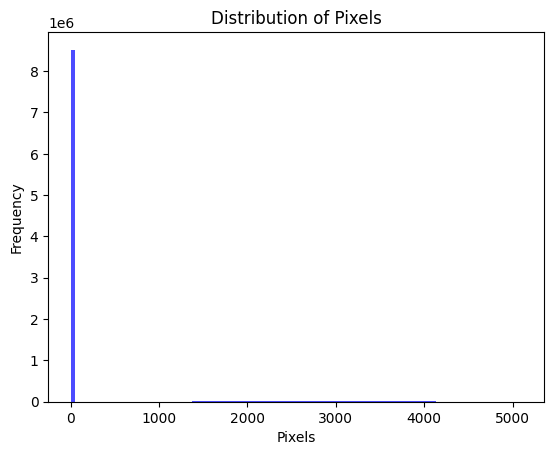

In [12]:
import matplotlib.pyplot as plt

# Assuming brain_mask is a NumPy array
plt.hist(extracted_image.numpy().flatten(), bins=100, color='blue', alpha=0.7)
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.title("Distribution of Pixels")
plt.show()

**[CHECKED]**

In [13]:
normalised_image = tio.RescaleIntensity(percentiles=(0, 99), masking_method=lambda x: x > 0)(extracted_image)

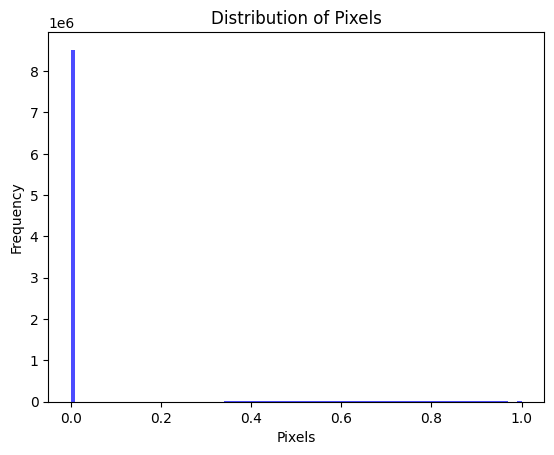

In [14]:
# Assuming brain_mask is a NumPy array
plt.hist(normalised_image.numpy().flatten(), bins=100, color='blue', alpha=0.7)
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.title("Distribution of Pixels")
plt.show()

**[CHECKED]**

In [15]:
resampled_image = tio.Resample((1, 1, 1))(normalised_image)
resampled_mask = tio.Resample((1, 1, 1))(binary_mask)

**[CHECKED]**

In [16]:
resized_image = tio.Resize(target_shape=128, image_interpolation='linear')(resampled_image)
resized_mask = tio.Resize(target_shape=128, image_interpolation='linear')(resampled_mask)

In [17]:
print(resized_image.shape)
print(resized_mask.shape)

torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])


**[CHECKED]**

In [18]:
import torch.nn.functional as F

In [19]:
shape = (1, 1, 16, 16, 16)
gaussian_noise = torch.rand(shape) * 0.2

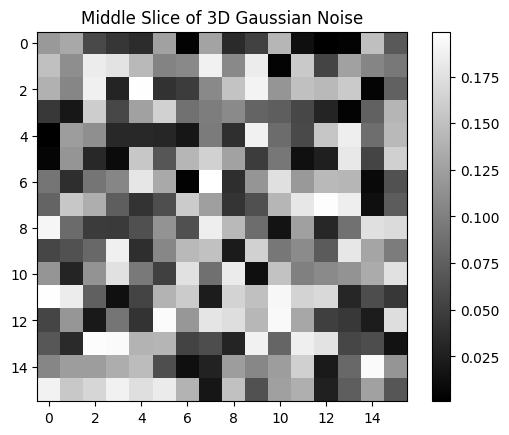

In [20]:
# Select the middle slice along the depth axis
mid_slice = gaussian_noise[0, 0, :, :, 8]  # Middle slice

# Plot the slice
plt.imshow(mid_slice.numpy(), cmap='gray')
plt.colorbar()
plt.title("Middle Slice of 3D Gaussian Noise")
plt.show()

In [21]:
# Upsample to 128x128x128 using trilinear interpolation
high_res_noise = F.interpolate(gaussian_noise, size=(128,128,128), mode='trilinear')

# Check shape
print("Upsampled Noise Shape:", high_res_noise.shape)  

Upsampled Noise Shape: torch.Size([1, 1, 128, 128, 128])


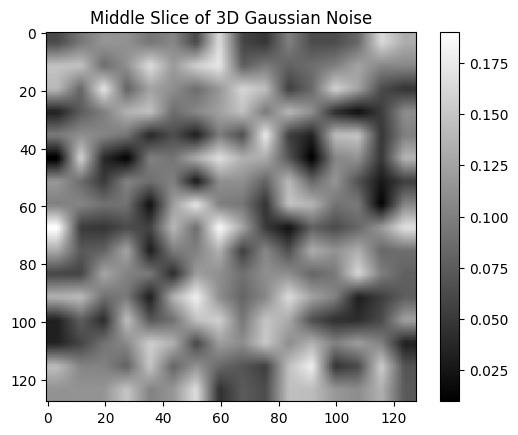

In [22]:
# Select the middle slice along the depth axis
mid_slice_upsampled = high_res_noise[0, 0, :, :, 63]  # Middle slice

# Plot the slice
plt.imshow(mid_slice_upsampled.numpy(), cmap='gray')
plt.colorbar()
plt.title("Middle Slice of 3D Gaussian Noise")
plt.show()

In [23]:
high_res_noise_sq = high_res_noise.squeeze(0)
augmented_noise = tio.transforms.RandomAffine(scales=0, degrees=0, translation=5)(high_res_noise_sq)

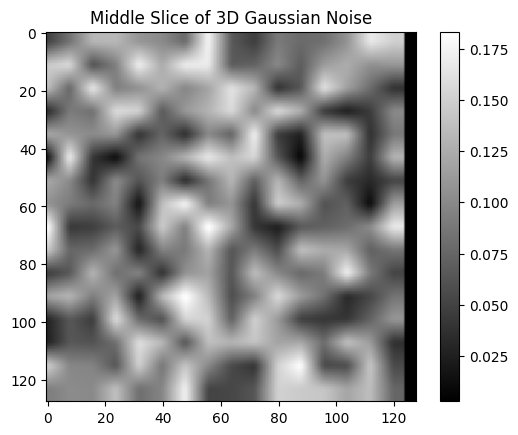

In [24]:
# Select the middle slice along the depth axis
mid_slice_modified = augmented_noise[0, :, :, 63]  # Middle slice

# Plot the slice
plt.imshow(mid_slice_modified.numpy(), cmap='gray')
plt.colorbar()
plt.title("Middle Slice of 3D Gaussian Noise")
plt.show()

**[CHECKED]**

In [31]:
duplicated = resized_image.clone()
print(duplicated.shape)
print(augmented_noise.shape)
print(resized_mask.shape)

torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])


In [32]:
noisy_image = duplicated + augmented_noise
noisy_image*= resized_mask

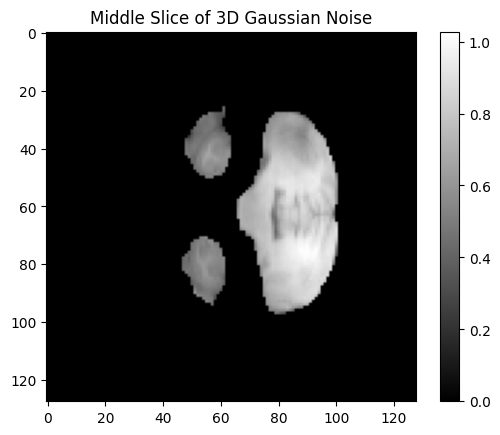

In [33]:
# Select the middle slice along the depth axis
mid = noisy_image[0, :, :, 63]  # Middle slice

# Plot the slice
plt.imshow(mid.numpy(), cmap='gray')
plt.colorbar()
plt.title("Middle Slice of 3D Gaussian Noise")
plt.show()

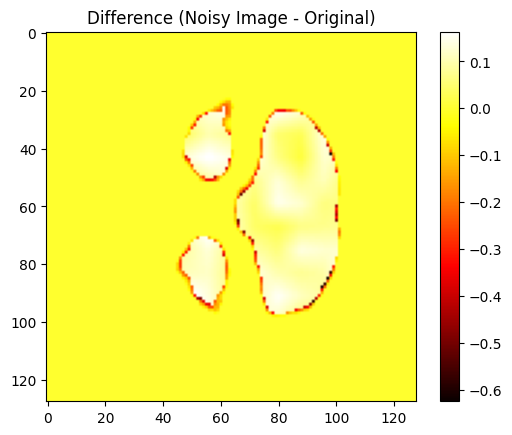

In [28]:
# Visualizing the difference between the original and noisy image
image_diff = noisy_image - duplicated
mid_diff = image_diff[0, :, :, 63]

# Plot the difference slice
plt.imshow(mid_diff.numpy(), cmap='hot')  # Use 'hot' colormap to highlight differences
plt.colorbar()
plt.title("Difference (Noisy Image - Original)")
plt.show()

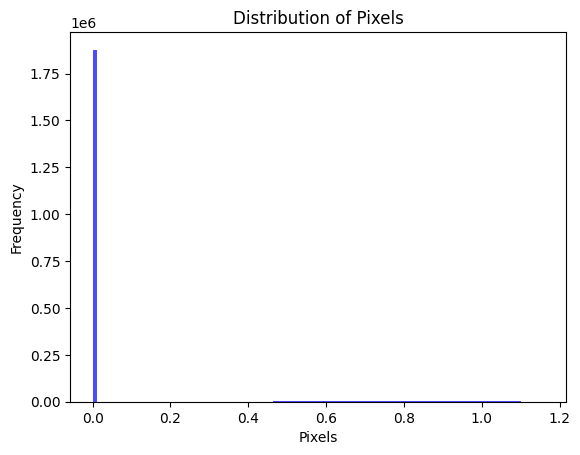

In [29]:
# Assuming brain_mask is a NumPy array
plt.hist(noisy_image.numpy().flatten(), bins=100, color='blue', alpha=0.7)
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.title("Distribution of Pixels")
plt.show()